In [12]:
!pip install nltk pandas matplotlib seaborn wordcloud -q

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re

from wordcloud import WordCloud
from nltk.sentiment.vader import SentimentIntensityAnalyzer

import nltk
nltk.download('vader_lexicon')

from google.colab import files

[nltk_data] Downloading package vader_lexicon to /root/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


In [14]:
from google.colab import files

uploaded = files.upload()

Saving Reviews.csv.zip to Reviews.csv (1).zip


In [15]:
df = pd.read_csv(
    "Reviews.csv.zip",
    usecols=["Score", "Time", "Summary", "Text"],
    nrows=50000
)

print("Dataset loaded successfully!")
print("Shape:", df.shape)

Dataset loaded successfully!
Shape: (50000, 4)


In [16]:
df.head()

,Score,Time,Summary,Text
0,5,1303862400,Good Quality Dog Food,I have bought several of the Vitality canned d...
1,1,1346976000,Not as Advertised,Product arrived labeled as Jumbo Salted Peanut...
2,4,1219017600,"""Delight"" says it all",This is a confection that has been around a fe...
3,2,1307923200,Cough Medicine,If you are looking for the secret ingredient i...
4,5,1350777600,Great taffy,Great taffy at a great price. There was a wid...


In [17]:
print(df.columns)

Index(['Score', 'Time', 'Summary', 'Text'], dtype='object')


In [18]:
print("Missing values:")
print(df.isnull().sum())

Missing values:
Score      0
Time       0
Summary    2
Text       0
dtype: int64


In [19]:
df = df.dropna(subset=["Text"])

df = df.reset_index(drop=True)

print("Dataset shape after removing missing reviews:")
print(df.shape)

Dataset shape after removing missing reviews:
(50000, 4)


In [21]:
def clean_text(text):
    text = str(text)

    text = text.lower()

    text = re.sub(r"http\S+|www\S+", "", text)

    text = re.sub(r"<.*?>", "", text)

    text = re.sub(r"[^a-zA-Z\s]", "", text)

    text = re.sub(r"\s+", " ", text).strip()

    return text

In [22]:
df["Cleaned_Text"] = df["Text"].apply(clean_text)

df[["Text", "Cleaned_Text"]].head()

,Text,Cleaned_Text
0,I have bought several of the Vitality canned d...,i have bought several of the vitality canned d...
1,Product arrived labeled as Jumbo Salted Peanut...,product arrived labeled as jumbo salted peanut...
2,This is a confection that has been around a fe...,this is a confection that has been around a fe...
3,If you are looking for the secret ingredient i...,if you are looking for the secret ingredient i...
4,Great taffy at a great price. There was a wid...,great taffy at a great price there was a wide ...


In [23]:
sia = SentimentIntensityAnalyzer()

In [24]:
def get_sentiment_scores(text):
    scores = sia.polarity_scores(text)

    return pd.Series([
        scores["neg"],
        scores["neu"],
        scores["pos"],
        scores["compound"]
    ])

df[["Negative_Score",
    "Neutral_Score",
    "Positive_Score",
    "Compound_Score"]] = df["Cleaned_Text"].apply(
        get_sentiment_scores
    )

df.head()

,Score,Time,Summary,Text,Cleaned_Text,Negative_Score,Neutral_Score,Positive_Score,Compound_Score
0,5,1303862400,Good Quality Dog Food,I have bought several of the Vitality canned d...,i have bought several of the vitality canned d...,0.000,0.695,0.305,0.9441
1,1,1346976000,Not as Advertised,Product arrived labeled as Jumbo Salted Peanut...,product arrived labeled as jumbo salted peanut...,0.138,0.862,0.000,-0.5664
2,4,1219017600,"""Delight"" says it all",This is a confection that has been around a fe...,this is a confection that has been around a fe...,0.091,0.754,0.155,0.8265
3,2,1307923200,Cough Medicine,If you are looking for the secret ingredient i...,if you are looking for the secret ingredient i...,0.000,0.925,0.075,0.4404
4,5,1350777600,Great taffy,Great taffy at a great price. There was a wid...,great taffy at a great price there was a wide ...,0.000,0.552,0.448,0.9468


In [25]:
def classify_sentiment(score):
    if score >= 0.05:
        return "Positive"

    elif score <= -0.05:
        return "Negative"

    else:
        return "Neutral"


df["Sentiment"] = df["Compound_Score"].apply(
    classify_sentiment
)

df[[
    "Text",
    "Compound_Score",
    "Sentiment"
]].head(10)

,Text,Compound_Score,Sentiment
0,I have bought several of the Vitality canned d...,0.9441,Positive
1,Product arrived labeled as Jumbo Salted Peanut...,-0.5664,Negative
2,This is a confection that has been around a fe...,0.8265,Positive
3,If you are looking for the secret ingredient i...,0.4404,Positive
4,Great taffy at a great price. There was a wid...,0.9468,Positive
5,I got a wild hair for taffy and ordered this f...,0.8253,Positive
6,This saltwater taffy had great flavors and was...,0.9273,Positive
7,This taffy is so good. It is very soft and ch...,0.9436,Positive
8,Right now I'm mostly just sprouting this so my...,0.6369,Positive
9,This is a very healthy dog food. Good for thei...,0.8313,Positive


In [26]:
sentiment_counts = df["Sentiment"].value_counts()

print(sentiment_counts)

Sentiment
Positive    43494
Negative     5372
Neutral      1134
Name: count, dtype: int64


In [27]:
sentiment_percentage = (
    df["Sentiment"]
    .value_counts(normalize=True)
    * 100
)

print(sentiment_percentage.round(2))

Sentiment
Positive    86.99
Negative    10.74
Neutral      2.27
Name: proportion, dtype: float64


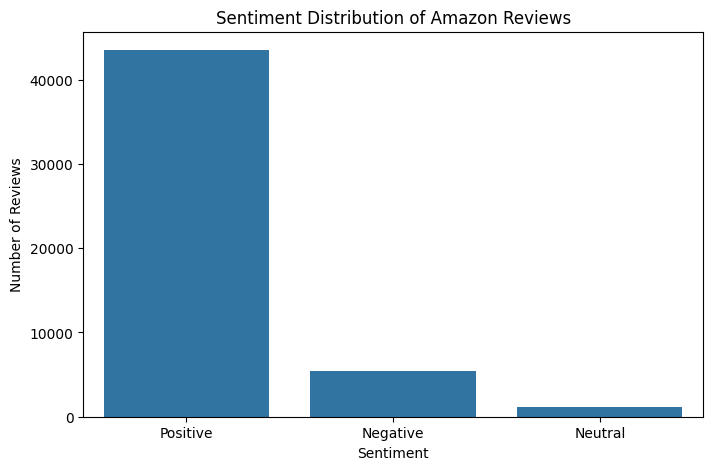

In [28]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="Sentiment"
)

plt.title("Sentiment Distribution of Amazon Reviews")
plt.xlabel("Sentiment")
plt.ylabel("Number of Reviews")

plt.show()

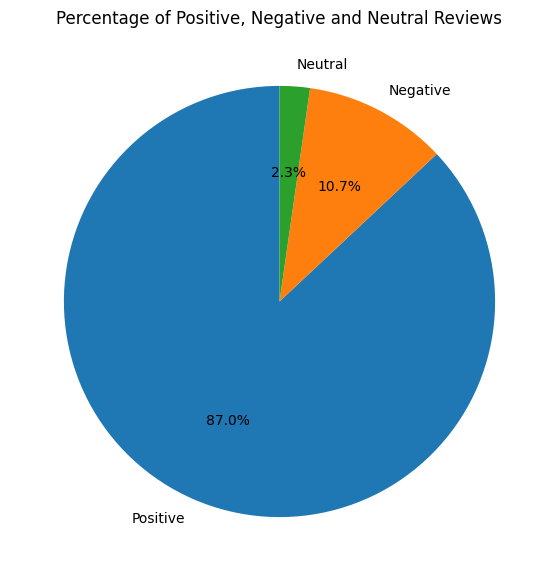

In [29]:
plt.figure(figsize=(7,7))

plt.pie(
    sentiment_counts,
    labels=sentiment_counts.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Percentage of Positive, Negative and Neutral Reviews")

plt.show()

In [30]:
print(df["Score"].value_counts().sort_index())

Score
1     4721
2     2814
3     4047
4     7288
5    31130
Name: count, dtype: int64


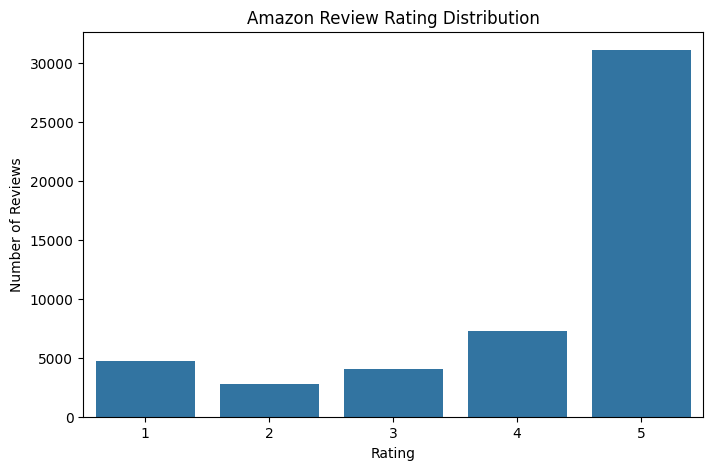

In [31]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="Score"
)

plt.title("Amazon Review Rating Distribution")
plt.xlabel("Rating")
plt.ylabel("Number of Reviews")

plt.show()

In [32]:
rating_sentiment = pd.crosstab(
    df["Score"],
    df["Sentiment"]
)

print(rating_sentiment)

Sentiment  Negative  Neutral  Positive
Score                                 
1              2173      268      2280
2               866      142      1806
3               729      173      3145
4               467      126      6695
5              1137      425     29568


<Figure size 1000x600 with 0 Axes>

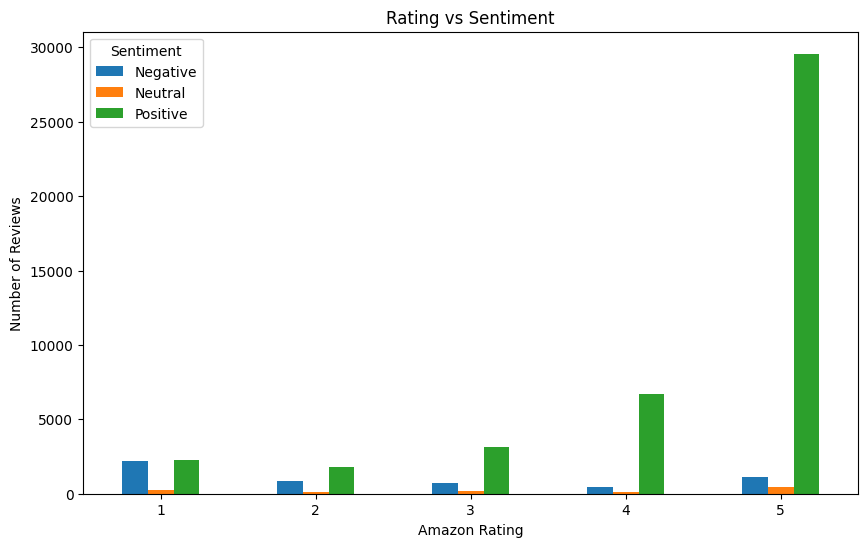

In [33]:
plt.figure(figsize=(10,6))

rating_sentiment.plot(
    kind="bar",
    figsize=(10,6)
)

plt.title("Rating vs Sentiment")
plt.xlabel("Amazon Rating")
plt.ylabel("Number of Reviews")

plt.xticks(rotation=0)

plt.show()

In [34]:
emotion_lexicon = {

    "Joy": [
        "happy", "love", "loved", "amazing",
        "excellent", "fantastic", "great",
        "wonderful", "awesome", "delicious",
        "perfect", "best", "enjoy"
    ],

    "Anger": [
        "angry", "hate", "hated", "terrible",
        "worst", "awful", "annoying",
        "frustrated", "disappointed"
    ],

    "Sadness": [
        "sad", "unhappy", "upset",
        "cry", "crying", "disappointed",
        "sorry", "loss"
    ],

    "Fear": [
        "fear", "afraid", "scared",
        "danger", "dangerous", "worried",
        "worry", "risk"
    ],

    "Surprise": [
        "surprised", "surprise",
        "shocking", "unexpected",
        "wow", "suddenly"
    ]
}

In [35]:
def detect_emotion(text):

    text = text.lower()

    emotion_scores = {}

    for emotion, words in emotion_lexicon.items():

        count = 0

        for word in words:
            count += len(
                re.findall(
                    r"\b" + re.escape(word) + r"\b",
                    text
                )
            )

        emotion_scores[emotion] = count

    max_emotion = max(
        emotion_scores,
        key=emotion_scores.get
    )

    if emotion_scores[max_emotion] == 0:
        return "Neutral"

    return max_emotion

In [36]:
df["Emotion"] = df["Cleaned_Text"].apply(
    detect_emotion
)

df[[
    "Text",
    "Sentiment",
    "Emotion"
]].head(20)

,Text,Sentiment,Emotion
0,I have bought several of the Vitality canned d...,Positive,Neutral
1,Product arrived labeled as Jumbo Salted Peanut...,Negative,Neutral
2,This is a confection that has been around a fe...,Positive,Neutral
3,If you are looking for the secret ingredient i...,Positive,Neutral
4,Great taffy at a great price. There was a wid...,Positive,Joy
5,I got a wild hair for taffy and ordered this f...,Positive,Neutral
6,This saltwater taffy had great flavors and was...,Positive,Joy
7,This taffy is so good. It is very soft and ch...,Positive,Joy
8,Right now I'm mostly just sprouting this so my...,Positive,Joy
9,This is a very healthy dog food. Good for thei...,Positive,Neutral


In [37]:
emotion_counts = df["Emotion"].value_counts()

print(emotion_counts)

Emotion
Joy         29987
Neutral     17288
Anger        1480
Surprise      569
Sadness       387
Fear          289
Name: count, dtype: int64


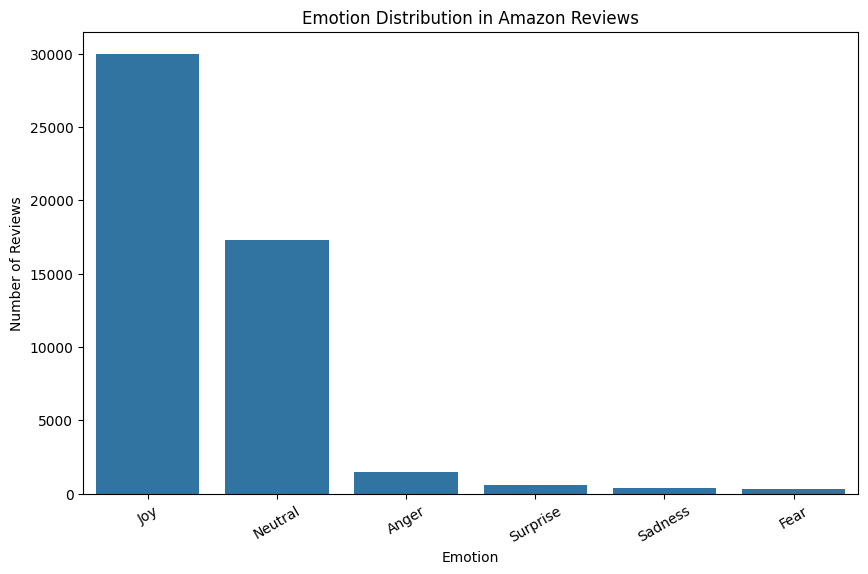

In [38]:
plt.figure(figsize=(10,6))

sns.countplot(
    data=df,
    x="Emotion",
    order=df["Emotion"].value_counts().index
)

plt.title("Emotion Distribution in Amazon Reviews")
plt.xlabel("Emotion")
plt.ylabel("Number of Reviews")

plt.xticks(rotation=30)

plt.show()

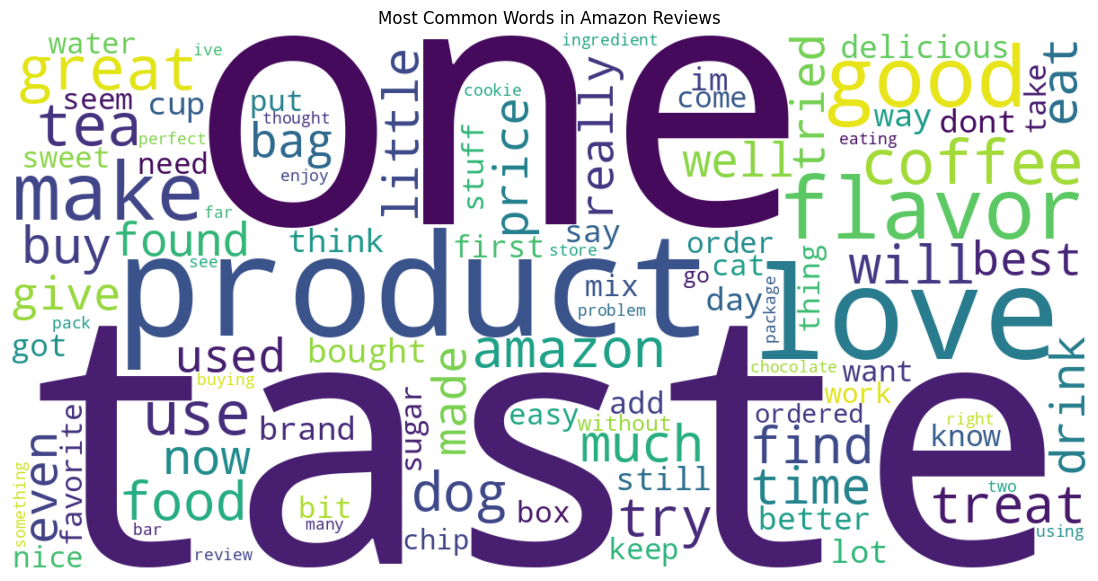

In [39]:
all_text = " ".join(
    df["Cleaned_Text"].astype(str)
)

wordcloud = WordCloud(
    width=1200,
    height=600,
    background_color="white",
    max_words=100
).generate(all_text)

plt.figure(figsize=(15,7))

plt.imshow(
    wordcloud,
    interpolation="bilinear"
)

plt.axis("off")

plt.title("Most Common Words in Amazon Reviews")

plt.show()

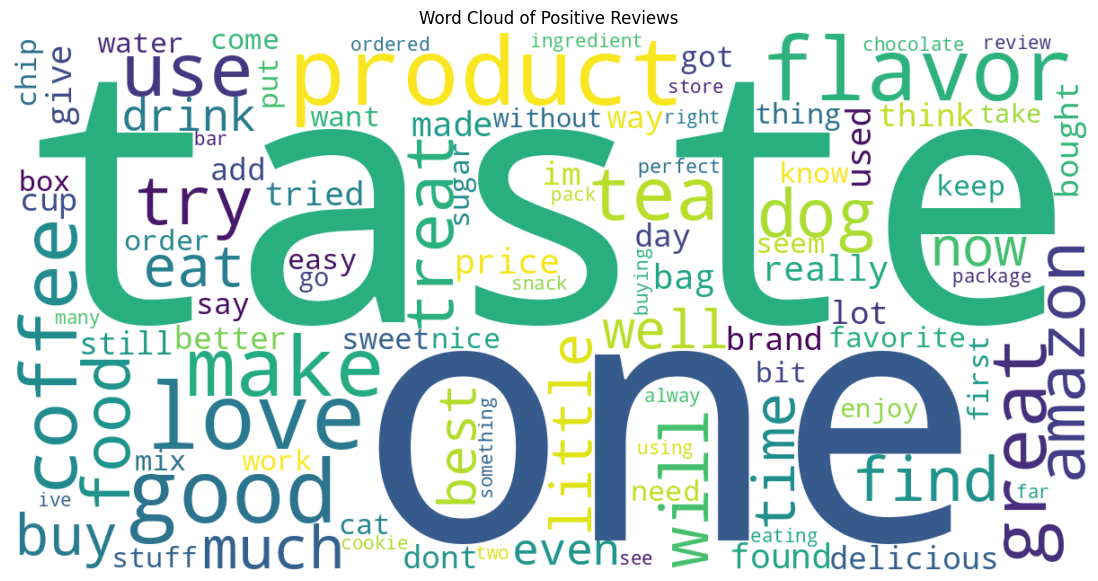

In [40]:
positive_text = " ".join(
    df[df["Sentiment"] == "Positive"]
    ["Cleaned_Text"]
    .astype(str)
)

positive_wordcloud = WordCloud(
    width=1200,
    height=600,
    background_color="white",
    max_words=100
).generate(positive_text)

plt.figure(figsize=(15,7))

plt.imshow(
    positive_wordcloud,
    interpolation="bilinear"
)

plt.axis("off")

plt.title("Word Cloud of Positive Reviews")

plt.show()

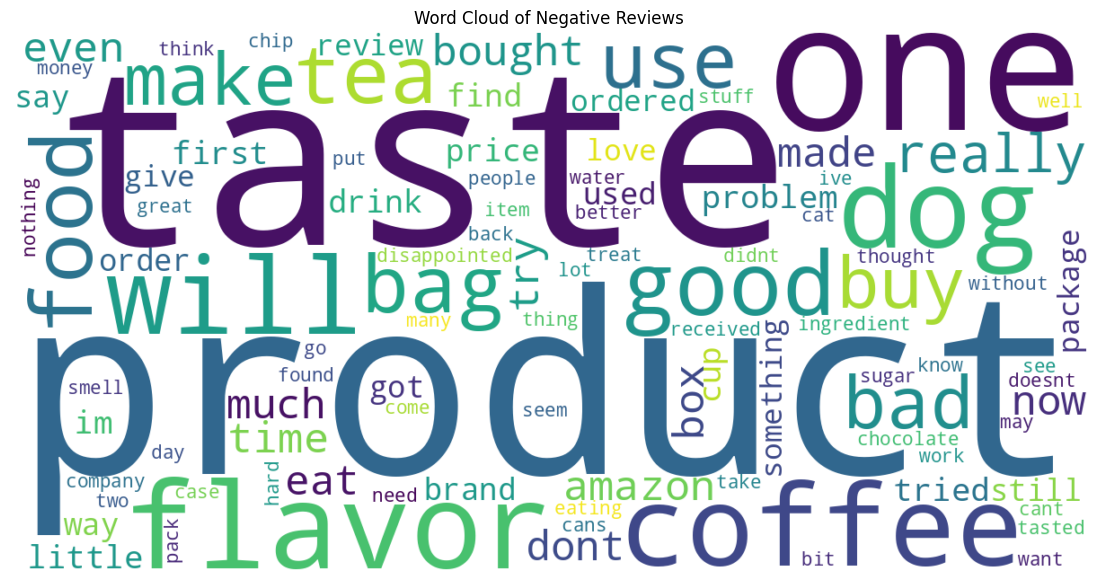

In [41]:
negative_text = " ".join(
    df[df["Sentiment"] == "Negative"]
    ["Cleaned_Text"]
    .astype(str)
)

negative_wordcloud = WordCloud(
    width=1200,
    height=600,
    background_color="white",
    max_words=100
).generate(negative_text)

plt.figure(figsize=(15,7))

plt.imshow(
    negative_wordcloud,
    interpolation="bilinear"
)

plt.axis("off")

plt.title("Word Cloud of Negative Reviews")

plt.show()

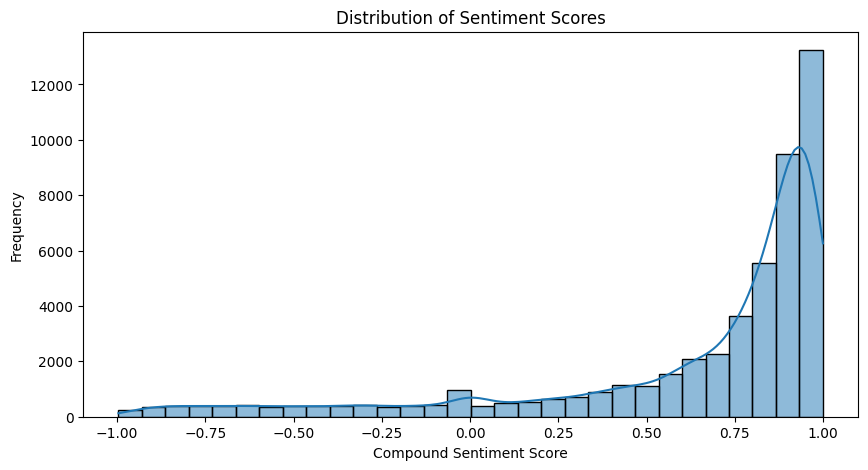

In [42]:
plt.figure(figsize=(10,5))

sns.histplot(
    df["Compound_Score"],
    bins=30,
    kde=True
)

plt.title("Distribution of Sentiment Scores")
plt.xlabel("Compound Sentiment Score")
plt.ylabel("Frequency")

plt.show()

In [43]:
df["Date"] = pd.to_datetime(
    df["Time"],
    unit="s"
)

df["Year"] = df["Date"].dt.year

df[["Date", "Year"]].head()

,Date,Year
0,2011-04-27,2011
1,2012-09-07,2012
2,2008-08-18,2008
3,2011-06-13,2011
4,2012-10-21,2012


In [44]:
yearly_sentiment = df.groupby(
    "Year"
)["Compound_Score"].mean()

print(yearly_sentiment)

Year
2000    0.875950
2003    0.757944
2004    0.728577
2005    0.670214
2006    0.672741
2007    0.663804
2008    0.662321
2009    0.655112
2010    0.636737
2011    0.624718
2012    0.627489
Name: Compound_Score, dtype: float64


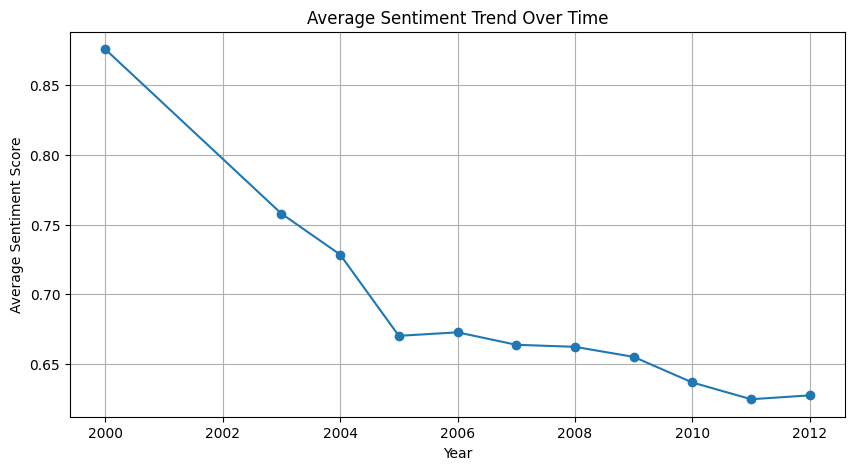

In [45]:
plt.figure(figsize=(10,5))

plt.plot(
    yearly_sentiment.index,
    yearly_sentiment.values,
    marker="o"
)

plt.title("Average Sentiment Trend Over Time")
plt.xlabel("Year")
plt.ylabel("Average Sentiment Score")

plt.grid(True)

plt.show()

In [46]:
most_positive = df.sort_values(
    "Compound_Score",
    ascending=False
)[[
    "Score",
    "Compound_Score",
    "Sentiment",
    "Text"
]].head(10)

display(most_positive)

,Score,Compound_Score,Sentiment,Text
1320,1,0.9997,Positive,"As another reviewer stated, many of the review..."
8756,5,0.9997,Positive,And we find her here upon this grand amazon!<b...
18191,5,0.9996,Positive,After a couple of days to try out these 2 Pean...
32241,5,0.9996,Positive,*****<br /><br />This Echinacea Immune Support...
29109,5,0.9996,Positive,"QUALITY<br />In my opinion, having used a doze..."
40206,4,0.9996,Positive,"I'm a confirmed hot chocolate snob and yes, I ..."
44203,5,0.9996,Positive,"I've been enjoying black, green, and herbal te..."
46566,5,0.9996,Positive,After a couple of days to try out these 2 Pean...
48204,5,0.9994,Positive,I was never a really big fan of ZICO natural b...
19567,5,0.9992,Positive,**Update: March 2012** I still feed this grai...


In [47]:
most_negative = df.sort_values(
    "Compound_Score",
    ascending=True
)[[
    "Score",
    "Compound_Score",
    "Sentiment",
    "Text"
]].head(10)

display(most_negative)

,Score,Compound_Score,Sentiment,Text
40225,1,-0.9966,Negative,I got a box of the Cafe Escapes Hot Chocolate ...
19568,1,-0.9955,Negative,My husband and I switched our three dogs to Ca...
31986,1,-0.9947,Negative,There have been ongoing problems with dented a...
18783,1,-0.9939,Negative,"Sure it tasted ok, but I drank it and about an..."
26525,1,-0.9903,Negative,Any whole grains that are cracked open can go ...
27826,2,-0.9893,Negative,Let's get one thing straight first: dogs love ...
38867,1,-0.9892,Negative,Some of gevalia's coffee is good. But their c...
14604,3,-0.9882,Negative,"Love this coffee, so I was rather disappointed..."
22396,1,-0.9870,Negative,I purchased the High Protein Pretzels. I've h...
6504,1,-0.9862,Negative,"After eating this product, I had a stomach ach..."


In [48]:
total_reviews = len(df)

positive = (
    df["Sentiment"] == "Positive"
).sum()

negative = (
    df["Sentiment"] == "Negative"
).sum()

neutral = (
    df["Sentiment"] == "Neutral"
).sum()

print("========== SENTIMENT ANALYSIS REPORT ==========")

print("Total Reviews:", total_reviews)

print(
    f"Positive Reviews: {positive} "
    f"({positive/total_reviews*100:.2f}%)"
)

print(
    f"Negative Reviews: {negative} "
    f"({negative/total_reviews*100:.2f}%)"
)

print(
    f"Neutral Reviews: {neutral} "
    f"({neutral/total_reviews*100:.2f}%)"
)

print(
    "Average Sentiment Score:",
    round(df["Compound_Score"].mean(), 3)
)

========== SENTIMENT ANALYSIS REPORT ==========
Total Reviews: 50000
Positive Reviews: 43494 (86.99%)
Negative Reviews: 5372 (10.74%)
Neutral Reviews: 1134 (2.27%)
Average Sentiment Score: 0.635


In [49]:
output_file = "CodeAlpha_Task4_Sentiment_Results.csv"

df.to_csv(
    output_file,
    index=False
)

print("File saved successfully:", output_file)

File saved successfully: CodeAlpha_Task4_Sentiment_Results.csv


In [50]:
files.download(
    "CodeAlpha_Task4_Sentiment_Results.csv"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>